In [1]:
import xarray as xr
import numpy as np
import os
import yaml
from xseas.stats.normalize import normalize_CMIP6
from xseas import load_models, evaluate_custom, tile_labels, train_perceptron, predict_custom, X_labels
from xseas.manager.utils import load_variables
from xseas.utils import day_of_year_to_date
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import mapping
import seaborn as sns
import matplotlib.patches as mpatches
import pymannkendall as mk
import pandas as pd

import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

from xseas import SeasonDetect
from pathlib import Path

import matplotlib as mpl

# Imposta stile globale
mpl.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 11,
    'axes.edgecolor': 'black',
    'axes.linewidth': 1,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

In [2]:
import yaml

with open('paths.local.yaml', 'r') as file:
    paths = yaml.safe_load(file)

FIGURES_DIR = Path(paths['FIGURES_DIR'])
SUPP_FIGURES_DIR = Path(paths['SUPP_FIGURES_DIR'])
WORKING_FOLDER = Path(paths['WORKING_FOLDER'])

In [3]:
# Ensure figures directory exists
FIGURES_DIR.mkdir(exist_ok=True)

# Define key paths
SHAPEFILES_PATH = WORKING_FOLDER / 'shapefiles'
REFERENCES_PATH = WORKING_FOLDER / 'references'
CLUSTERING_PATH = WORKING_FOLDER / 'clusterings'
CONFIG_FILE = 'four_seas_all_vars.yaml'

In [4]:
# Load boundaries data
coastlines = gpd.read_file(SHAPEFILES_PATH / 'coastlines.gpkg')
boundary = gpd.read_file(SHAPEFILES_PATH / 'boundary.gpkg')

# Load analysis results
s = SeasonDetect(WORKING_FOLDER, 'four_seas_all_vars.yaml')

In [5]:
monsoon_reference_all_vars = CLUSTERING_PATH/'four_seas_all_vars_clust.nc'

# Create the labels for the training
lables_param = {'n_seas': 4}

monsoon_reference_all_vars = xr.open_dataset(monsoon_reference_all_vars).breakpoints
monsoon_reference_all_vars = X_labels(monsoon_reference_all_vars, **lables_param)

monsoon_seas_reference = monsoon_reference_all_vars.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
monsoon_seas_reference.rio.write_crs("epsg:4326", inplace=True);

In [6]:
def load_and_clip(name):

    nnull = 0
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    if name == 'southwest_india':
        nnull = 18
    elif name == 'HKK':
        nnull = 35
    elif name == 'him':
        nnull = 105
    elif name == 'central_india':
        nnull = 90

    all_models = []
    for model in s.CMIP6_models:
        if os.path.exists(os.path.join(s.perceptron_path, 'historical_prediction', f'historical_pred_{s.name}_{model}.nc')):
            dataset_hist = xr.open_dataset(os.path.join(s.perceptron_path, 'historical_prediction', f'historical_pred_{s.name}_{model}.nc'))
        if os.path.exists(os.path.join(s.perceptron_path, 'future_prediction', f'future_pred_{s.name}_{model}.nc')):
            dataset_fut = xr.open_dataset(os.path.join(s.perceptron_path, 'future_prediction', f'future_pred_{s.name}_{model}.nc'))
        
        try:
            all_models.append(xr.concat([dataset_hist, dataset_fut], dim='time'))
        except:
            print(f"Model {model} not found")
            continue



    all_models = xr.concat(all_models, dim='model',coords='minimal', compat='override')
    all_models = all_models.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    all_models.rio.write_crs("epsg:4326", inplace=True);
    all_models = all_models.rio.clip(bnd.geometry.apply(mapping))
    return all_models, bnd, nnull

def load_and_clip_performance(name):
    bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

    all_models = []
    for model in s.CMIP6_models:
        if os.path.exists(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc')):
            dataset_eval = xr.open_dataset(os.path.join(s.perceptron_path, 'evaluation', f'eval_{s.name}_{model}.nc'))
            all_models.append(dataset_eval)

    all_models = xr.concat(all_models, dim='model',coords='minimal', compat='override')
    all_models = all_models.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
    all_models.rio.write_crs("epsg:4326", inplace=True);
    all_models = all_models.rio.clip(bnd.geometry.apply(mapping))

    f1 = 2 * (all_models.precision * all_models.recall) / (all_models.precision + all_models.recall)
    return all_models, f1, all_models.precision, all_models.recall

In [7]:
def do_mk_test(data):
    """
    Esegue il test di Mann-Kendall sui dati forniti.
    Restituisce il valore p e la tendenza.
    """
    result = mk.original_test(data, alpha=0.05)
    return result.p, result.trend, result.slope, result.h



def mk_test(season_st, dat):

    da = dat.sel(time=slice('2020', '2090')) 
    data = da.where(da == season_st).groupby('time.year').count().predictions

    # Applicare la funzione a ogni modello usando apply_ufunc
    p_value, trends, slope, h = xr.apply_ufunc(
        do_mk_test, 
        data,  # Media annuale
        input_core_dims=[["year"]],  # Specifica che il test viene applicato lungo "year"
        output_core_dims=[[], [], [], []],  # Output scalari per ogni modello
        vectorize=True,  # Abilita la vettorizzazione per iterare su ogni modello
        dask="parallelized",  # Supporto per Dask se i dati sono grandi
        output_dtypes=[float, object, float, object]  # Tipi di dati di output
    )

    return p_value, trends, slope, h



def build_ssme(f1, season_st, dat):

    # Condizione di significatività
    significant_mask_f1 = f1.sel(cluster=season_st) > 0.7

    # Maschera unificata
    significant_pixels = significant_mask_f1

    # Maschera finale
    masked_data = dat.where(significant_pixels)

    return masked_data, significant_pixels

In [8]:
def figure_slope_map_double_mod(dat, season_st_list, f1, names=['monsoon', 'winter']):
    fig, axs = plt.subplots(1, 2, figsize=(7, 5))  

    for season_st, ax, name in zip(season_st_list, axs, names):
        
        # Calcola SSME e media annuale per modello
        ssme, significant_pixels = build_ssme(f1, season_st, dat)
        ssme_season = ssme.where(ssme.predictions == season_st).groupby('time.year').count()
        ssme_avg = ssme_season.mean(dim='model')

        # Applica test di Mann-Kendall
        p_value, trends, slope, h = xr.apply_ufunc(
            do_mk_test, 
            ssme_avg,
            input_core_dims=[["year"]],
            output_core_dims=[[], [], [], []],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float, object, float, object]
        )

        # Trova punti marini
        seas_point = dat.sel(time=slice('2000', '2005')).predictions.sum(dim='model').sum('time') == 0

        # Calcola i valori di slope e maschere
        slope_vals = slope.predictions * 10
        non_significant_mask = p_value.predictions > 0.05
        nan_mask = xr.ufuncs.isnan(slope_vals)

        # Maschera combinata: non significativo o nan, ma non mare
        mask2d = (non_significant_mask | nan_mask) & ~seas_point

        # Maschera slope solo dove significativo
        slope_significant = slope_vals.where(~mask2d)

        # Rimuovi punti marini
        slope_significant = slope_significant.where(~seas_point)

        # Plot dei valori di slope
        slope_significant.plot(
            cmap='coolwarm',
            vmin=-1.5,
            vmax=1.5,
            add_colorbar=False,
            levels=[-1.5, -1.0, -0.5, 0.5, 1.0, 1.5],
            extend='both',
            ax=ax
        )

        # Scatter dei punti non significativi
        lat_coords, lon_coords = np.meshgrid(slope.lat, slope.lon, indexing="ij")
        lat_coords_non_sign = lat_coords[mask2d]
        lon_coords_non_sign = lon_coords[mask2d]
        ax.scatter(lon_coords_non_sign, lat_coords_non_sign, color="black", marker="x", s=12, label="Non significativo")

        # Aggiungi contorno regione
        boundary.boundary.plot(ax=ax, color='black', lw=0.5)

        # Limiti e stile assi
        ax.set_xlim(65, 100)
        ax.set_ylim(5, 40)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.grid(True, alpha=0.5)
        ax.set_title('')
        ax.set_xlabel('Longitude [°E]', fontsize=12)
        ax.set_ylabel('')

    # Etichette asse Y solo sulla prima mappa
    axs[0].set_ylabel('Latitude [°N]', fontsize=12)

    # Colorbar condivisa
    cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='horizontal', pad=0.2, aspect=50, extend='both')
    cbar.ax.tick_params(labelsize=12)
    cbar.ax.set_xlabel('Slope\n[days/decade]', fontsize=12)
    cbar.outline.set_visible(False)

    # Etichette (A) e (B)
    axs[0].text(0.0, 1.1, f'a) {names[0]}', transform=axs[0].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')
    axs[1].text(0.0, 1.1, f'b) {names[1]}', transform=axs[1].transAxes, fontsize=12, fontweight='bold', va='top', ha='left')

    plt.show()
    return fig, axs

In [ ]:
dat, _, nnull = load_and_clip('boundary')
_, f1, precision, recall = load_and_clip_performance('boundary') 

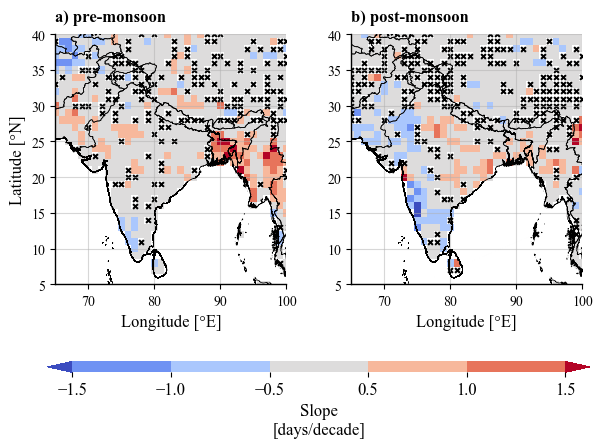

In [ ]:
fig, axs = figure_slope_map_double_mod(dat, [1,3], f1, ['pre-monsoon', 'post-monsoon'])
s_trend_path = SUPP_FIGURES_DIR / 'spatial_trends_supplementary.png'
fig.savefig(s_trend_path, dpi=300, bbox_inches='tight', transparent=True)

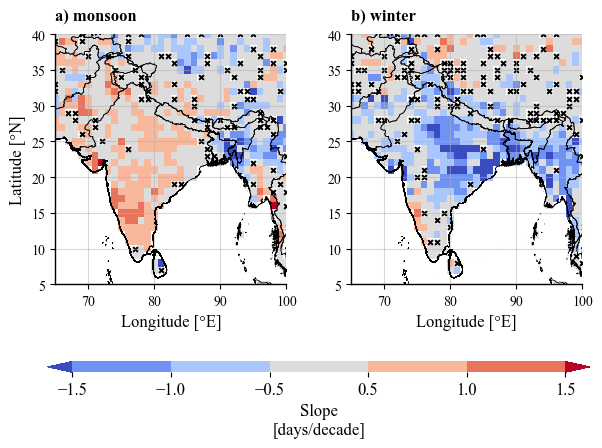

In [ ]:
fig, axs = figure_slope_map_double_mod(dat, [2,0], f1)
s_trend_path = FIGURES_DIR / 'spatial_trends.png'
fig.savefig(s_trend_path, dpi=300, bbox_inches='tight', transparent=True)

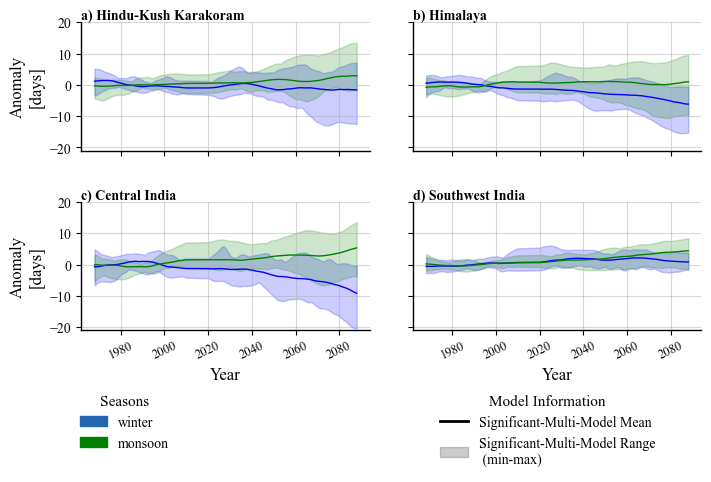

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(8, 4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.15) 

for s_ind, col in zip([0,2], ['blue', 'green']):

    masked_data, significant_pixels = build_ssme(f1, s_ind, dat)

    ref = masked_data.sel(time=slice('1970','2020')).where(masked_data == s_ind).groupby('time.year').count().predictions.mean('year')
    anomaly = masked_data.sel(time=slice('1960','2095')).where(masked_data == s_ind).groupby('time.year').count().predictions - ref
    anomaly = anomaly.rolling(year=15, center=True).mean().rename('')

    for name, ax in zip([ 'HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

        bnd = gpd.read_file(SHAPEFILES_PATH/f'{name}.gpkg')

        c = anomaly.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
        c = c.rio.write_crs("epsg:4326", inplace=True);
        c = c.rio.clip(bnd.geometry.apply(mapping))

        c.mean(['lat','lon']).mean('model').plot(ax=ax, lw=1, color=col)
        
        min = c.mean(['lat','lon']).min('model')
        max = c.mean(['lat','lon']).max('model')
        
        mean = c.mean(['lat','lon']).mean('model')

        ax.fill_between(c.year, min, max, alpha=0.2, color=col, label=None)

        ax.grid(True, alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title('')
        ax.set_xticks(np.arange(1960, 2110, 20))
        ax.set_xticklabels(np.arange(1960, 2110, 20), rotation=25, fontsize=9)
        ax.set_xlabel('')

axs[0][0].text(0.0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[0][1].text(0.0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[1][0].text(0.0, 1.1, 'c) Central India', transform=axs[1][0].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[1][1].text(0.0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

axs[1][0].set_xlabel('Year', fontsize=12)
axs[1][1].set_xlabel('Year', fontsize=12)

axs[0][0].set_ylabel('Anomaly\n[days]', fontsize=12)
axs[1][0].set_ylabel('Anomaly\n[days]', fontsize=12)

axs[0][0].set_ylim(-21, 11)
axs[0][0].set_yticks(np.arange(-20, 21, 10))
axs[1][0].set_yticks(np.arange(-20, 21, 10))


# Creazione delle Patch per la legenda
legend_patches = [
    # mpatches.Patch(color='blue',  label='Short term\n(2020-2040)'),
    mpatches.Patch(color='#2166ac',  label='winter'),
    mpatches.Patch(color='green',  label='monsoon'),
]

axs[1][1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-1.2, -0.4), fontsize=10, frameon=False, title='Seasons')

# Legenda tecnica (riga inferiore sinistra)
axs[1][0].plot([], [], color='k', lw=2, label='Significant-Multi-Model Mean')
axs[1][0].fill_between([], [], [], color='k', alpha=0.2, label='Significant-Multi-Model Range\n (min-max)')

axs[1][0].legend(loc='upper left', bbox_to_anchor=(1.2, -0.4), fontsize=10, frameon=False, title='Model Information')

plt.show()
seasonal_path = FIGURES_DIR / 'seasonal_increment.png'
fig.savefig(seasonal_path, dpi=300, bbox_inches='tight', transparent=True)

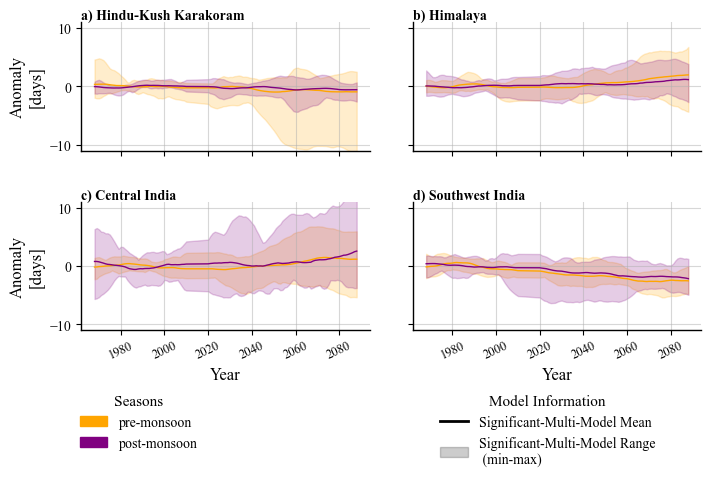

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(8, 4), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.4, wspace=0.15) 

for s_ind, col in zip([1,3], ['orange', 'purple']):

    masked_data, significant_pixels = build_ssme(f1, s_ind, dat)

    ref = masked_data.sel(time=slice('1970','2020')).where(masked_data == s_ind).groupby('time.year').count().predictions.mean('year')
    anomaly = masked_data.sel(time=slice('1960','2095')).where(masked_data == s_ind).groupby('time.year').count().predictions - ref
    anomaly = anomaly.rolling(year=15, center=True).mean().rename('')

    for name, ax in zip([ 'HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

        bnd = gpd.read_file(/SHAPEFILES_PATHf'{name}.gpkg')

        c = anomaly.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
        c = c.rio.write_crs("epsg:4326", inplace=True);
        c = c.rio.clip(bnd.geometry.apply(mapping))

        c.mean(['lat','lon']).mean('model').plot(ax=ax, lw=1, color=col)
        
        min = c.mean(['lat','lon']).min('model')
        max = c.mean(['lat','lon']).max('model')

        mean = c.mean(['lat','lon']).mean('model')
        std = c.std(['lat','lon']).mean('model')
        ax.fill_between(c.year, min, max, alpha=0.2, color=col, label=None)

        ax.grid(True, alpha=0.5)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title('')
        ax.set_xticks(np.arange(1960, 2110, 20))
        ax.set_xticklabels(np.arange(1960, 2110, 20), rotation=25, fontsize=9)
        ax.set_xlabel('')

axs[0][0].text(0.0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[0][1].text(0.0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[1][0].text(0.0, 1.1, 'c) Central India', transform=axs[1][0].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')
axs[1][1].text(0.0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes, fontsize=10, fontweight='bold', va='top', ha='left')

axs[1][0].set_xlabel('Year', fontsize=12)
axs[1][1].set_xlabel('Year', fontsize=12)

axs[0][0].set_ylabel('Anomaly\n[days]', fontsize=12)
axs[1][0].set_ylabel('Anomaly\n[days]', fontsize=12)

axs[0][0].set_ylim(-11, 11)
axs[0][0].set_yticks(np.arange(-10, 11, 10))
axs[1][0].set_yticks(np.arange(-10, 11, 10))


# Creazione delle Patch per la legenda
legend_patches = [
    # mpatches.Patch(color='blue',  label='Short term\n(2020-2040)'),
    mpatches.Patch(color='orange',  label='pre-monsoon'),
    mpatches.Patch(color='purple',  label='post-monsoon'),
]

axs[1][1].legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(-1.2, -0.4), fontsize=10, frameon=False, title='Seasons')

# Legenda tecnica (riga inferiore sinistra)
axs[1][0].plot([], [], color='k', lw=2, label='Significant-Multi-Model Mean')
axs[1][0].fill_between([], [], [], color='k', alpha=0.2, label='Significant-Multi-Model Range\n (min-max)')

axs[1][0].legend(loc='upper left', bbox_to_anchor=(1.2, -0.4), fontsize=10, frameon=False, title='Model Information')

plt.show()
seasonal_increment_supplement_path = SUPP_FIGURES_DIR / 'seasonal_increment_supplementary.png'
fig.savefig(seasonal_increment_supplement_path, dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
def figure_seasonal_increment(dat, season_st, f1):

    # Test statistico e mascheratura
    masked_data, significant_pixels = build_ssme(f1, season_st, dat)

    # Climatologia di riferimento (1970–2000)
    cycle_ref = masked_data.sel(time=slice('1970', '2000')).where(masked_data == season_st).resample(time='1ME').count()
    cycle_ref = cycle_ref.groupby('time.month').mean(dim='time', skipna=True)

    # Setup figure
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    # Posizioni centrali dei mesi (DOY)
    base_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

    # Periodi e stili
    periods_list = [['2040', '2060'], ['2060','2080'],['2080', '2100']]
    colors = ["#c7e9c0", "#74c476", "#00441b"]
    offsets = [-6,0,6]  # sfalsamento laterale per boxplot affiancati

    for periods, color, offset in zip(periods_list, colors, offsets):

        # Proiezione per periodo
        cycle_proj = masked_data.sel(time=slice(periods[0], periods[1])).where(masked_data == season_st).resample(time='1ME').count()
        cycle_proj = cycle_proj.groupby('time.month').mean(dim='time', skipna=True)

        a = cycle_ref.predictions
        b = cycle_proj.predictions

        for name, ax in zip(['HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

            bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

            # Differenza tra proiezione e riferimento
            c = (b - a)
            c = c.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            c = c.rio.write_crs("epsg:4326", inplace=True)
            c = c.rio.clip(bnd.geometry.apply(mapping))

            # Ristrutturazione dati
            d = c.values.reshape(12, -1)
            df = pd.DataFrame(d.T, columns=[i + 1 for i in range(12)])
            df_melt = df.melt(var_name='Month', value_name='Incremento')

            # Boxplot mensili
            positions = [p + offset for p in base_positions]
            month_data = [df_melt[df_melt['Month'] == m]['Incremento'].dropna().values for m in range(1, 13)]

            ax.boxplot(month_data, positions=positions, widths=6, patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor=color, color='k'),
                       medianprops=dict(color='k'),
                       whiskerprops=dict(color='k'),
                       capprops=dict(color='k'))
                       #flierprops=dict(marker='o', markersize=.5, markerfacecolor=color, alpha=0.3))

            # Stile asse
            ax.grid(True, alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_ylim(-10, 18)
            ax.set_xticks(base_positions)
            ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45, fontsize=9)
            ax.set_yticks(np.arange(-10, 16, 5))
            ax.set_xlim(121, 305)

    # Etichette assi Y
    axs[0][0].set_ylabel('Increment\n[days]', fontsize=12)
    axs[1][0].set_ylabel('Increment\n[days]', fontsize=12)

    # Etichette assi X
    axs[1][0].set_xlabel('Month', fontsize=12)
    axs[1][1].set_xlabel('Month', fontsize=12)

    # Titoli subplot
    axs[0][0].text(0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[0][1].text(0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][0].text(0, 1.1, 'c) Central India', transform=axs[1][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][1].text(0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')

    # Legenda
    legend_patches = [
        mpatches.Patch(color='#c7e9c0', label='2040–2060'),
        mpatches.Patch(color='#74c476', label='2060–2080'),
        mpatches.Patch(color='#00441b', label='2080–2100')
    ]
    axs[1][1].legend(handles=legend_patches, loc='upper left',
                     bbox_to_anchor=(-0.68, -0.5), fontsize=10, frameon=False, title='Periods', ncol=3), 

    plt.show()

    return fig, axs

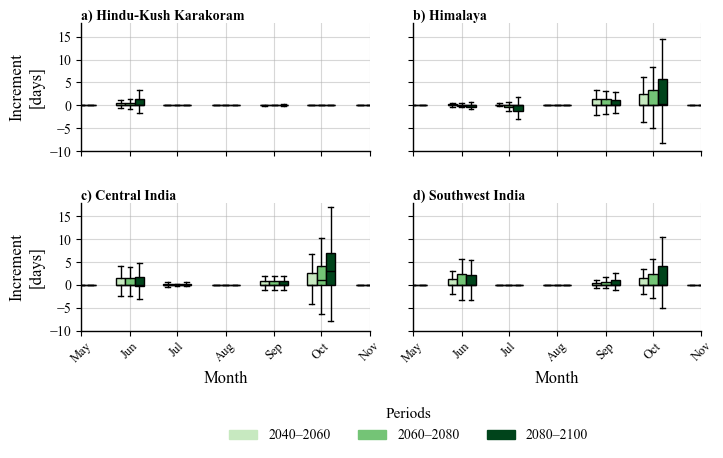

In [ ]:
for seas in [2]:
    fig, ax = figure_seasonal_increment(dat, seas, f1)

monthly_increment_path = FIGURES_DIR / 'monthly_increment_monsoon.png'
fig.savefig(monthly_increment_path, dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def figure_seasonal_increment(dat, season_st, f1):

    # Test statistico e mascheratura
    masked_data, significant_pixels = build_ssme(f1, season_st, dat)

    # Climatologia di riferimento (1970–2000)
    cycle_ref = masked_data.sel(time=slice('1970', '2000')).where(masked_data == season_st).resample(time='1ME').count()
    cycle_ref = cycle_ref.groupby('time.month').mean(dim='time', skipna=True)

    # Setup figura
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    month_order = [10, 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    month_labels = ['Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr',
                    'May', 'Jun', 'Jul', 'Aug', 'Sep']
    base_positions = [1 + 30 * i for i in range(12)]  # 1, 31, ..., 331
    offsets = [-6, 0, 6]  # sfalsamento per boxplot affiancati

    # Periodi e colori
    periods_list = [['2040', '2060'], ['2060', '2080'], ['2080', '2100']]
    colors = ["#c6dbef", "#6baed6", "#08306b"]

    for periods, color, offset in zip(periods_list, colors, offsets):

        cycle_proj = masked_data.sel(time=slice(periods[0], periods[1])).where(masked_data == season_st).resample(time='1ME').count()
        cycle_proj = cycle_proj.groupby('time.month').mean(dim='time', skipna=True)

        a = cycle_ref.predictions
        b = cycle_proj.predictions

        for name, ax in zip(['HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

            bnd = gpd.read_file(SHAPEFILES_PATH/f'{name}.gpkg')

            # Differenza tra proiezione e riferimento
            c = (b - a)
            c = c.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            c = c.rio.write_crs("epsg:4326", inplace=True)
            c = c.rio.clip(bnd.geometry.apply(mapping))

            d = c.values.reshape(12, -1)
            df = pd.DataFrame(d.T, columns=[i + 1 for i in range(12)])
            df_melt = df.melt(var_name='Month', value_name='Incremento')

            # Reordering data by new month order
            month_data = [df_melt[df_melt['Month'] == m]['Incremento'].dropna().values for m in month_order]
            positions = [p + offset for p in base_positions]

            ax.boxplot(month_data, positions=positions, widths=6, patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor=color, color='k'),
                       medianprops=dict(color='k'),
                       whiskerprops=dict(color='k'),
                       capprops=dict(color='k'))

            ax.grid(True, alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_ylim(-20, 12)
            ax.set_xticks(base_positions)
            ax.set_xticklabels(month_labels, rotation=45, fontsize=9)
            ax.set_yticks(np.arange(-20, 11, 5))

            # Zoom su mesi novembre–marzo
            ax.set_xlim(base_positions[0] - 10, base_positions[4] + 10)

    # Etichette assi Y
    axs[0][0].set_ylabel('Increment\n[days]', fontsize=12)
    axs[1][0].set_ylabel('Increment\n[days]', fontsize=12)

    # Etichette assi X
    axs[1][0].set_xlabel('Month', fontsize=12)
    axs[1][1].set_xlabel('Month', fontsize=12)

    # Titoli subplot
    axs[0][0].text(0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[0][1].text(0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][0].text(0, 1.1, 'c) Central India', transform=axs[1][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][1].text(0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')

    # Legenda
    legend_patches = [
        mpatches.Patch(color="#c6dbef", label='2040–2060'),
        mpatches.Patch(color="#6baed6", label='2060–2080'),
        mpatches.Patch(color="#08306b", label='2080–2100')
    ]
    axs[1][1].legend(handles=legend_patches, loc='upper left',
                     bbox_to_anchor=(-0.68, -0.5), fontsize=10, frameon=False, title='Periods', ncol=3)

    plt.show()
    return fig, axs

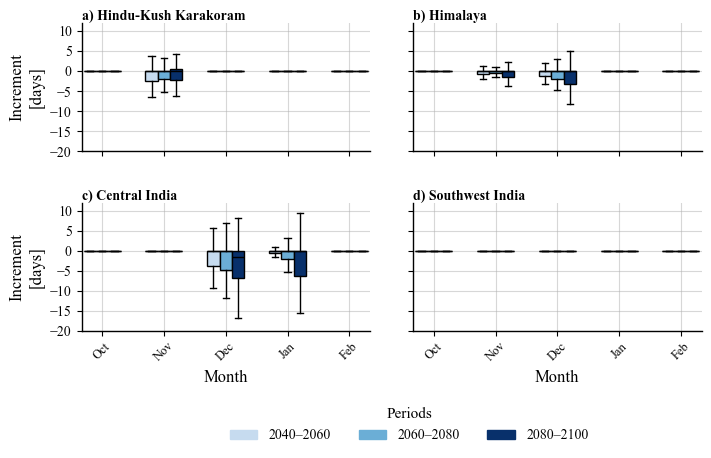

In [ ]:
for seas in [0]:
    fig, ax = figure_seasonal_increment(dat, seas, f1)

monthly_increment_path = FIGURES_DIR / 'monthly_increment_winter.png'
fig.savefig(monthly_increment_path, dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
def figure_seasonal_increment(dat, season_st, f1):

    # Test statistico e mascheratura
    masked_data, significant_pixels = build_ssme(f1, season_st, dat)

    # Climatologia di riferimento (1970–2000)
    cycle_ref = masked_data.sel(time=slice('1970', '2000')).where(masked_data == season_st).resample(time='1ME').count()
    cycle_ref = cycle_ref.groupby('time.month').mean(dim='time', skipna=True)

    # Setup figure
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    # Posizioni centrali dei mesi (DOY)
    base_positions = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]

    # Periodi e stili
    periods_list = [['2040', '2060'], ['2060','2080'],['2080', '2100']]
    colors = ["yellow", "orange", "red"]
    offsets = [-6,0,6]  # sfalsamento laterale per boxplot affiancati

    for periods, color, offset in zip(periods_list, colors, offsets):

        # Proiezione per periodo
        cycle_proj = masked_data.sel(time=slice(periods[0], periods[1])).where(masked_data == season_st).resample(time='1ME').count()
        cycle_proj = cycle_proj.groupby('time.month').mean(dim='time', skipna=True)

        a = cycle_ref.predictions
        b = cycle_proj.predictions

        for name, ax in zip(['HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

            bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

            # Differenza tra proiezione e riferimento
            c = (b - a)
            c = c.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            c = c.rio.write_crs("epsg:4326", inplace=True)
            c = c.rio.clip(bnd.geometry.apply(mapping))

            # Ristrutturazione dati
            d = c.values.reshape(12, -1)
            df = pd.DataFrame(d.T, columns=[i + 1 for i in range(12)])
            df_melt = df.melt(var_name='Month', value_name='Incremento')

            # Boxplot mensili
            positions = [p + offset for p in base_positions]
            month_data = [df_melt[df_melt['Month'] == m]['Incremento'].dropna().values for m in range(1, 13)]

            ax.boxplot(month_data, positions=positions, widths=6, patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor=color, color='k'),
                       medianprops=dict(color='k'),
                       whiskerprops=dict(color='k'),
                       capprops=dict(color='k'))
                       #flierprops=dict(marker='o', markersize=.5, markerfacecolor=color, alpha=0.3))

            # Stile asse
            ax.grid(True, alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_ylim(-10, 6)
            ax.set_xticks(base_positions)
            ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45, fontsize=9)
            ax.set_yticks(np.arange(-10, 6, 5))
            ax.set_xlim(32, 213)

    # Etichette assi Y
    axs[0][0].set_ylabel('Increment\n[days]', fontsize=12)
    axs[1][0].set_ylabel('Increment\n[days]', fontsize=12)

    # Etichette assi X
    axs[1][0].set_xlabel('Month', fontsize=12)
    axs[1][1].set_xlabel('Month', fontsize=12)

    # Titoli subplot
    axs[0][0].text(0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[0][1].text(0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][0].text(0, 1.1, 'c) Central India', transform=axs[1][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][1].text(0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')

    # Legenda
    legend_patches = [
        mpatches.Patch(color='yellow', label='2040–2060'),
        mpatches.Patch(color='orange', label='2060–2080'),
        mpatches.Patch(color='red', label='2080–2100')
    ]
    axs[1][1].legend(handles=legend_patches, loc='upper left',
                     bbox_to_anchor=(-0.68, -0.5), fontsize=10, frameon=False, title='Periods', ncol=3), 

    plt.show()

    return fig, axs

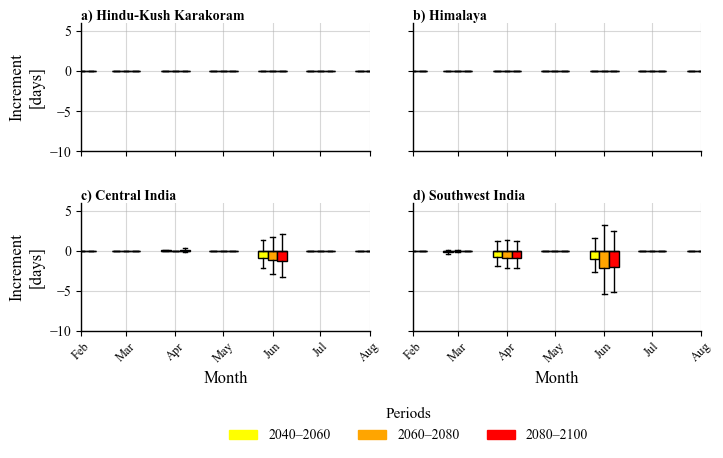

In [ ]:
for seas in [1]:
    fig, ax = figure_seasonal_increment(dat, seas, f1)

monthly_increment_path = SUPP_FIGURES_DIR / 'monthly_increment_premonsoon.png'
fig.savefig(monthly_increment_path, dpi=300, bbox_inches='tight', transparent=True)

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def figure_seasonal_increment(dat, season_st, f1):

    # Test statistico e mascheratura
    masked_data, significant_pixels = build_ssme(f1, season_st, dat)

    # Climatologia di riferimento (1970–2000)
    cycle_ref = masked_data.sel(time=slice('1970', '2000')).where(masked_data == season_st).resample(time='1ME').count()
    cycle_ref = cycle_ref.groupby('time.month').mean(dim='time', skipna=True)

    # Setup figura
    fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, sharey=True)
    plt.subplots_adjust(hspace=0.4, wspace=0.15)

    month_order = [8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7]
    month_labels = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb', 'Mar', 'Apr',
                    'May', 'Jun', 'Jul']
    base_positions = [1 + 30 * i for i in range(12)]  # 1, 31, ..., 331
    offsets = [-6, 0, 6]  # sfalsamento per boxplot affiancati

    # Periodi e colori
    periods_list = [['2040', '2060'], ['2060', '2080'], ['2080', '2100']]
    colors = ["#fbb4d9", "#c51b8a", "#7a0177"]

    for periods, color, offset in zip(periods_list, colors, offsets):

        cycle_proj = masked_data.sel(time=slice(periods[0], periods[1])).where(masked_data == season_st).resample(time='1ME').count()
        cycle_proj = cycle_proj.groupby('time.month').mean(dim='time', skipna=True)

        a = cycle_ref.predictions
        b = cycle_proj.predictions

        for name, ax in zip(['HKK', 'him', 'central_india', 'southwest_india'], axs.flatten()):

            bnd = gpd.read_file(SHAPEFILES_PATH / f'{name}.gpkg')

            # Differenza tra proiezione e riferimento
            c = (b - a)
            c = c.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
            c = c.rio.write_crs("epsg:4326", inplace=True)
            c = c.rio.clip(bnd.geometry.apply(mapping))

            d = c.values.reshape(12, -1)
            df = pd.DataFrame(d.T, columns=[i + 1 for i in range(12)])
            df_melt = df.melt(var_name='Month', value_name='Incremento')

            # Reordering data by new month order
            month_data = [df_melt[df_melt['Month'] == m]['Incremento'].dropna().values for m in month_order]
            positions = [p + offset for p in base_positions]

            ax.boxplot(month_data, positions=positions, widths=6, patch_artist=True, showfliers=False,
                       boxprops=dict(facecolor=color, color='k'),
                       medianprops=dict(color='k'),
                       whiskerprops=dict(color='k'),
                       capprops=dict(color='k'))

            ax.grid(True, alpha=0.5)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.set_ylim(-20, 16)
            ax.set_xticks(base_positions)
            ax.set_xticklabels(month_labels, rotation=45, fontsize=9)
            ax.set_yticks(np.arange(-20, 16, 5))

            # Zoom su mesi novembre–marzo
            ax.set_xlim(base_positions[1] - 10, base_positions[6] + 10)

    # Etichette assi Y
    axs[0][0].set_ylabel('Increment\n[days]', fontsize=12)
    axs[1][0].set_ylabel('Increment\n[days]', fontsize=12)

    # Etichette assi X
    axs[1][0].set_xlabel('Month', fontsize=12)
    axs[1][1].set_xlabel('Month', fontsize=12)

    # Titoli subplot
    axs[0][0].text(0, 1.1, 'a) Hindu-Kush Karakoram', transform=axs[0][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[0][1].text(0, 1.1, 'b) Himalaya', transform=axs[0][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][0].text(0, 1.1, 'c) Central India', transform=axs[1][0].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')
    axs[1][1].text(0, 1.1, 'd) Southwest India', transform=axs[1][1].transAxes,
                   fontsize=10, fontweight='bold', va='top', ha='left')

    # Legenda
    legend_patches = [
        mpatches.Patch(color="#fbb4d9", label='2040–2060'),
        mpatches.Patch(color="#c51b8a", label='2060–2080'),
        mpatches.Patch(color="#7a0177", label='2080–2100')
    ]
    axs[1][1].legend(handles=legend_patches, loc='upper left',
                     bbox_to_anchor=(-0.68, -0.5), fontsize=10, frameon=False, title='Periods', ncol=3)

    plt.show()
    return fig, axs

In [ ]:
for seas in [3]:
    fig, ax = figure_seasonal_increment(dat, seas, f1)

monthly_increment_path = SUPP_FIGURES_DIR / 'monthly_increment_postmonsoon.png'
fig.savefig(monthly_increment_path, dpi=300, bbox_inches='tight', transparent=True)